In [1]:
!pip install pandas


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
!pip install openpyxl


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Load the dataset
df = pd.read_excel(r'Data_Train.xlsx')

# Display the first few rows
print(df.head())

# Get basic information and summary statistics
print(df.info())
print(df.describe(include='all'))

# Check for missing values
print(df.isnull().sum())

# Convert 'Date_of_Journey' to datetime
df['Date_of_Journey'] = pd.to_datetime(df['Date_of_Journey'], format='%d/%m/%Y')

# Convert 'Price' to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Function to extract time in 'HH:MM' format from the string
def extract_time(time_str):
    match = re.match(r'(\d{2}:\d{2})', time_str)
    if match:
        return match.group(1)
    return None

# Clean and extract time from 'Dep_Time' and 'Arrival_Time'
df['Dep_Time_Cleaned'] = df['Dep_Time'].apply(extract_time)
df['Arrival_Time_Cleaned'] = df['Arrival_Time'].apply(extract_time)

# Extract hours and minutes from cleaned times
df['Dep_Hour'] = df['Dep_Time_Cleaned'].str.split(':').str[0].astype(int)
df['Dep_Minute'] = df['Dep_Time_Cleaned'].str.split(':').str[1].astype(int)

df['Arrival_Hour'] = df['Arrival_Time_Cleaned'].str.split(':').str[0].astype(int)
df['Arrival_Minute'] = df['Arrival_Time_Cleaned'].str.split(':').str[1].astype(int)

# Function to convert duration to hours
def duration_to_hours(duration):
    if 'h' in duration:
        parts = duration.split('h')
        hours = parts[0].strip()
        minutes = parts[1].replace('m', '').strip() if len(parts) > 1 else '0'
    else:
        hours = '0'
        minutes = duration.replace('m', '').strip()

    try:
        return int(hours) + int(minutes) / 60
    except ValueError:
        return np.nan

# Convert 'Duration' to hours
df['Duration_Hours'] = df['Duration'].apply(duration_to_hours)

# Fill missing 'Duration_Hours' with median or other imputation strategy
df['Duration_Hours'].fillna(df['Duration_Hours'].median(), inplace=True)

# Feature engineering: extract day, month, and year from 'Date_of_Journey'
df['Day_of_Journey'] = df['Date_of_Journey'].dt.day
df['Month_of_Journey'] = df['Date_of_Journey'].dt.month
df['Year_of_Journey'] = df['Date_of_Journey'].dt.year



       Airline Date_of_Journey    Source Destination                  Route  \
0       IndiGo      24/03/2019  Banglore   New Delhi              BLR → DEL   
1    Air India       1/05/2019   Kolkata    Banglore  CCU → IXR → BBI → BLR   
2  Jet Airways       9/06/2019     Delhi      Cochin  DEL → LKO → BOM → COK   
3       IndiGo      12/05/2019   Kolkata    Banglore        CCU → NAG → BLR   
4       IndiGo      01/03/2019  Banglore   New Delhi        BLR → NAG → DEL   

  Dep_Time  Arrival_Time Duration Total_Stops Additional_Info  Price  
0    22:20  01:10 22 Mar   2h 50m    non-stop         No info   3897  
1    05:50         13:15   7h 25m     2 stops         No info   7662  
2    09:25  04:25 10 Jun      19h     2 stops         No info  13882  
3    18:05         23:30   5h 25m      1 stop         No info   6218  
4    16:50         21:35   4h 45m      1 stop         No info  13302  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 

C:\Users\upend\AppData\Local\Temp\ipykernel_23904\1526518523.py:63: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Duration_Hours'].fillna(df['Duration_Hours'].median(), inplace=True)


# Visualization

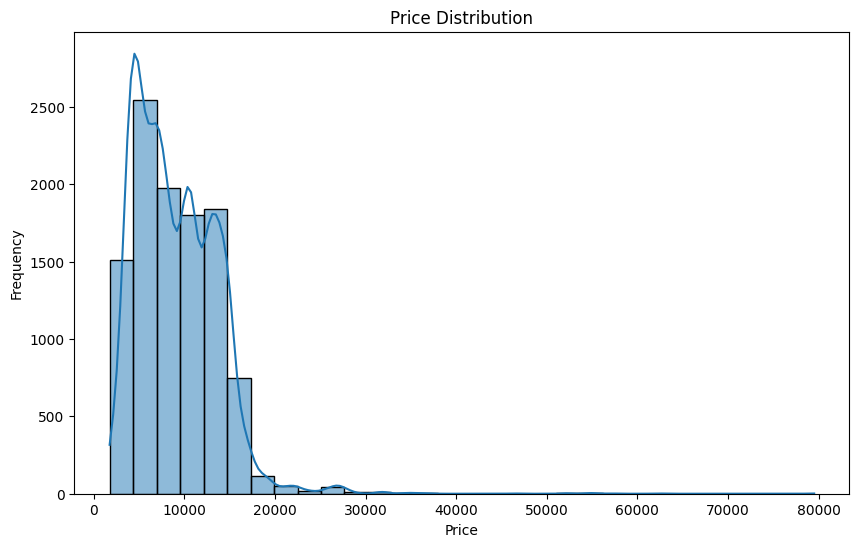

In [5]:


# Distribution of prices
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=30, kde=True)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()


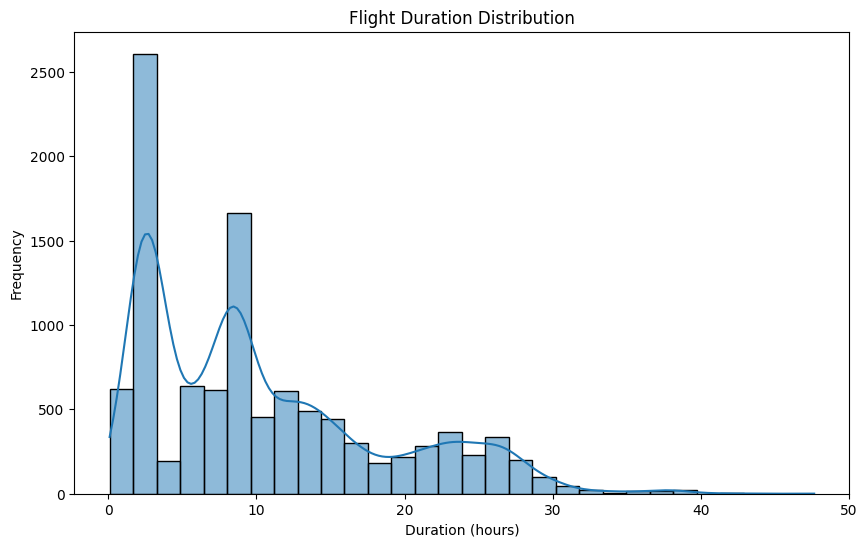

In [6]:
# Distribution of flight durations
plt.figure(figsize=(10, 6))
sns.histplot(df['Duration_Hours'], bins=30, kde=True)
plt.title('Flight Duration Distribution')
plt.xlabel('Duration (hours)')
plt.ylabel('Frequency')
plt.show()


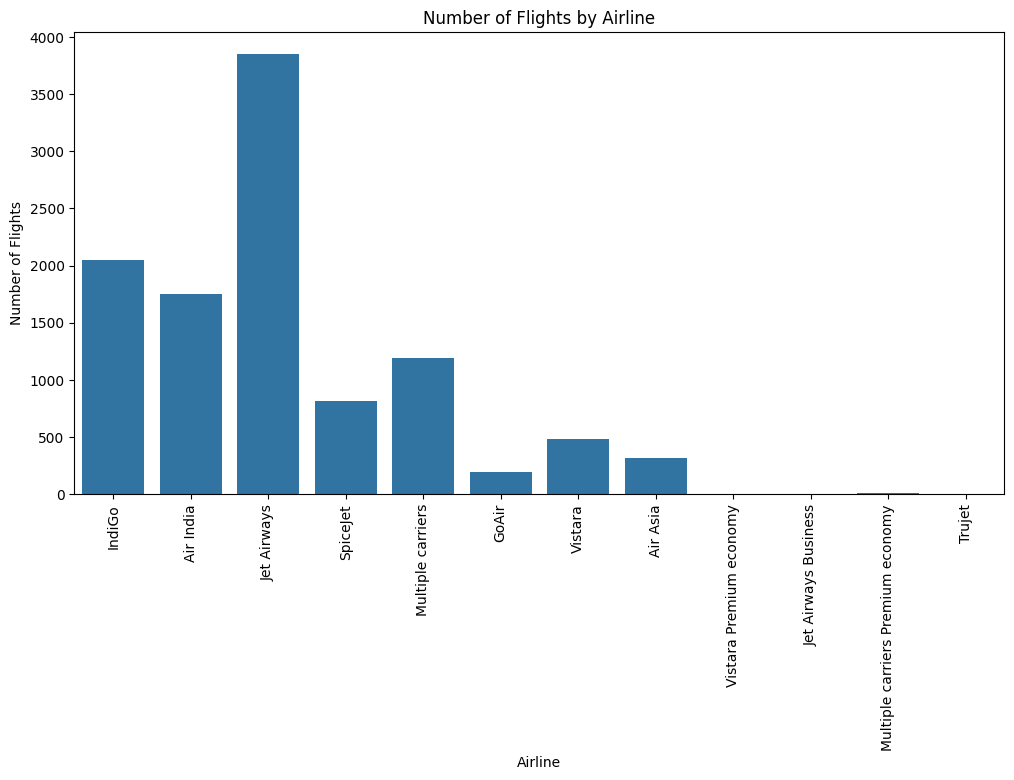

In [7]:
# Number of flights by airline
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Airline')
plt.title('Number of Flights by Airline')
plt.xticks(rotation=90)
plt.xlabel('Airline')
plt.ylabel('Number of Flights')
plt.show()

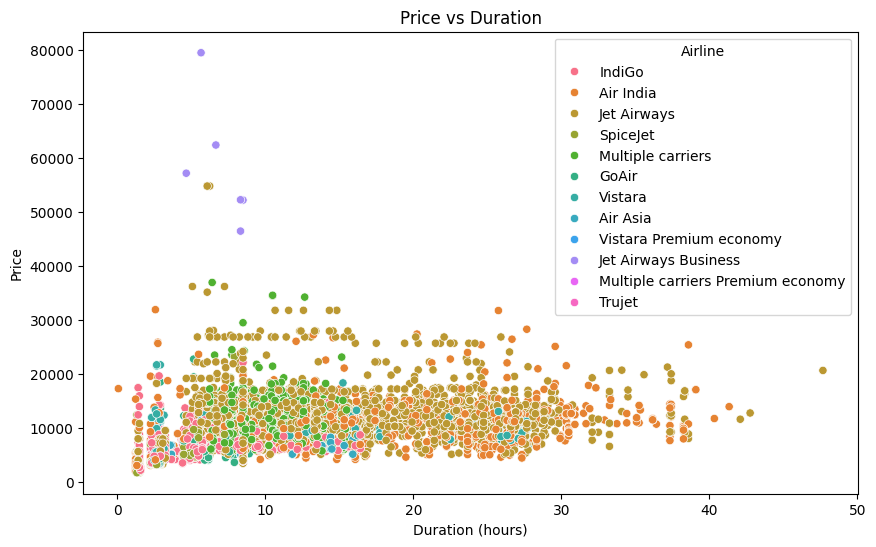

In [8]:
# Price vs Duration
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Duration_Hours', y='Price', hue='Airline')
plt.title('Price vs Duration')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.show()

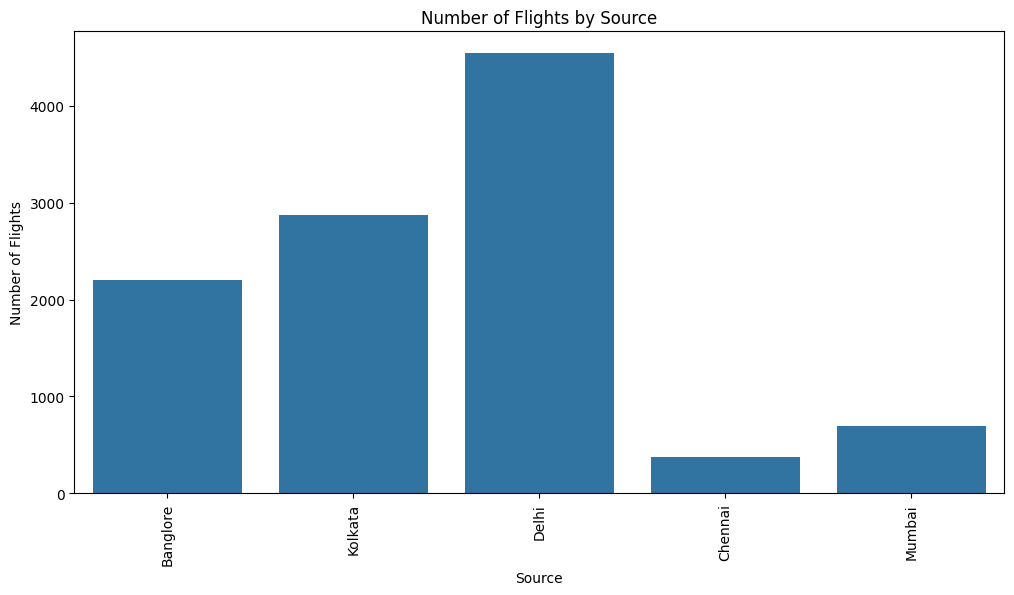

In [9]:
# Number of flights by source
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Source')
plt.title('Number of Flights by Source')
plt.xticks(rotation=90)
plt.xlabel('Source')
plt.ylabel('Number of Flights')
plt.show()


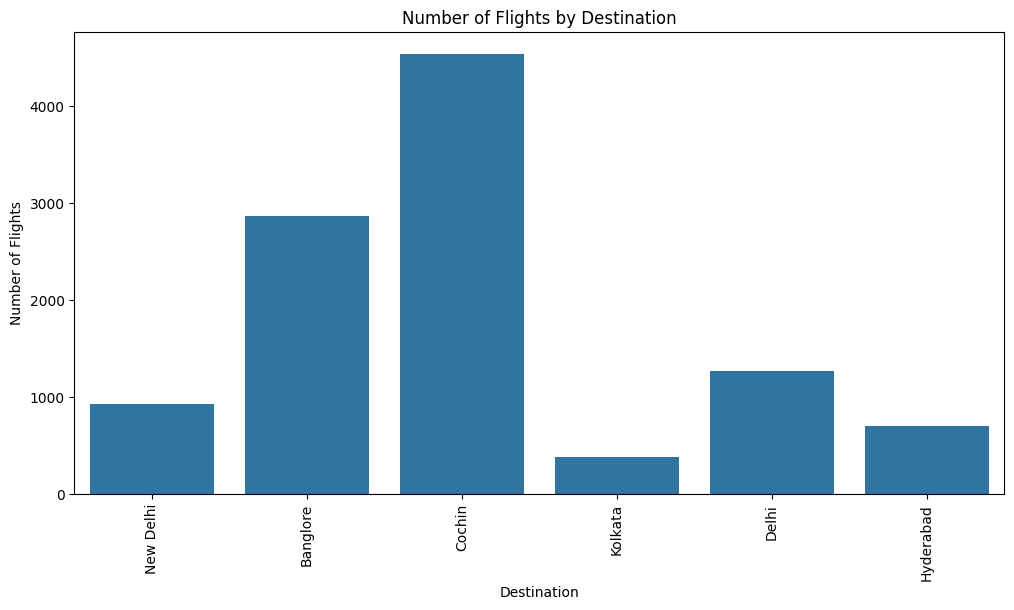

In [10]:
# Number of flights by destination
plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='Destination')
plt.title('Number of Flights by Destination')
plt.xticks(rotation=90)
plt.xlabel('Destination')
plt.ylabel('Number of Flights')
plt.show()

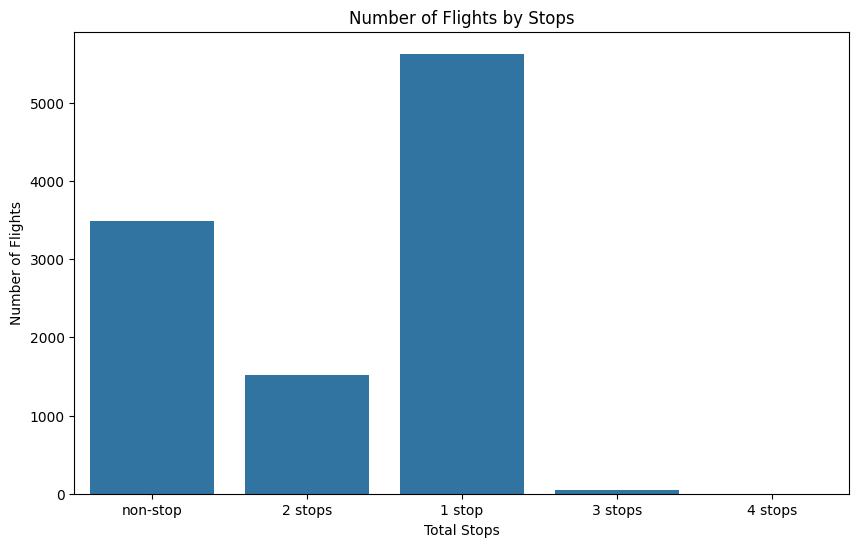

In [11]:
# Number of flights by stops
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Total_Stops')
plt.title('Number of Flights by Stops')
plt.xlabel('Total Stops')
plt.ylabel('Number of Flights')
plt.show()

In [12]:
df

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,...,Dep_Time_Cleaned,Arrival_Time_Cleaned,Dep_Hour,Dep_Minute,Arrival_Hour,Arrival_Minute,Duration_Hours,Day_of_Journey,Month_of_Journey,Year_of_Journey
0,IndiGo,2019-03-24,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,...,22:20,01:10,22,20,1,10,2.833333,24,3,2019
1,Air India,2019-05-01,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,...,05:50,13:15,5,50,13,15,7.416667,1,5,2019
2,Jet Airways,2019-06-09,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,...,09:25,04:25,9,25,4,25,8.500000,9,6,2019
3,IndiGo,2019-05-12,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,...,18:05,23:30,18,5,23,30,5.416667,12,5,2019
4,IndiGo,2019-03-01,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,...,16:50,21:35,16,50,21,35,4.750000,1,3,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,2019-04-09,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,...,19:55,22:25,19,55,22,25,2.500000,9,4,2019
10679,Air India,2019-04-27,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,...,20:45,23:20,20,45,23,20,2.583333,27,4,2019
10680,Jet Airways,2019-04-27,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,...,08:20,11:20,8,20,11,20,8.500000,27,4,2019
10681,Vistara,2019-03-01,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,...,11:30,14:10,11,30,14,10,2.666667,1,3,2019


In [13]:
df.columns

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price', 'Dep_Time_Cleaned', 'Arrival_Time_Cleaned',
       'Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute',
       'Duration_Hours', 'Day_of_Journey', 'Month_of_Journey',
       'Year_of_Journey'],
      dtype='object')

In [14]:
# Convert the 'Route' column to string
df['Route'] = df['Route'].astype(str)

# Function to extract locations from the route
def extract_locations(route):
    return re.findall(r'[A-Za-z]+', route)

# Apply the function to create a 'Locations' column
df['Locations'] = df['Route'].apply(extract_locations)

# Extract all unique locations
all_locations = set([loc for sublist in df['Locations'] for loc in sublist])
print("Unique Locations:", all_locations)

# Create binary columns for each location
for location in all_locations:
    df[location] = df['Locations'].apply(lambda x: 1 if location in x else 0)

# Drop the 'Locations' column as it is no longer needed
df.drop(columns=['Date_of_Journey','Locations','Route','Dep_Time','Arrival_Time','Duration','Dep_Hour', 'Dep_Minute', 'Arrival_Hour', 'Arrival_Minute'], inplace=True)

Unique Locations: {'COK', 'JLR', 'IMF', 'STV', 'KNU', 'PAT', 'DEL', 'HYD', 'VGA', 'BOM', 'BLR', 'LKO', 'PNQ', 'NAG', 'CCU', 'IXR', 'IDR', 'GWL', 'UDR', 'BDQ', 'AMD', 'IXB', 'BBI', 'DED', 'GAU', 'JDH', 'RPR', 'GOI', 'ISK', 'ATQ', 'IXU', 'HBX', 'nan', 'JAI', 'TRV', 'MAA', 'IXA', 'VNS', 'IXC', 'IXZ', 'VTZ', 'BHO', 'NDC'}


In [15]:
df

,Airline,Source,Destination,Total_Stops,Additional_Info,Price,Dep_Time_Cleaned,Arrival_Time_Cleaned,Duration_Hours,Day_of_Journey,...,JAI,TRV,MAA,IXA,VNS,IXC,IXZ,VTZ,BHO,NDC
0,IndiGo,Banglore,New Delhi,non-stop,No info,3897,22:20,01:10,2.833333,24,...,0,0,0,0,0,0,0,0,0,0
1,Air India,Kolkata,Banglore,2 stops,No info,7662,05:50,13:15,7.416667,1,...,0,0,0,0,0,0,0,0,0,0
2,Jet Airways,Delhi,Cochin,2 stops,No info,13882,09:25,04:25,8.500000,9,...,0,0,0,0,0,0,0,0,0,0
3,IndiGo,Kolkata,Banglore,1 stop,No info,6218,18:05,23:30,5.416667,12,...,0,0,0,0,0,0,0,0,0,0
4,IndiGo,Banglore,New Delhi,1 stop,No info,13302,16:50,21:35,4.750000,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,Kolkata,Banglore,non-stop,No info,4107,19:55,22:25,2.500000,9,...,0,0,0,0,0,0,0,0,0,0
10679,Air India,Kolkata,Banglore,non-stop,No info,4145,20:45,23:20,2.583333,27,...,0,0,0,0,0,0,0,0,0,0
10680,Jet Airways,Banglore,Delhi,non-stop,No info,7229,08:20,11:20,8.500000,27,...,0,0,0,0,0,0,0,0,0,0
10681,Vistara,Banglore,New Delhi,non-stop,No info,12648,11:30,14:10,2.666667,1,...,0,0,0,0,0,0,0,0,0,0


In [16]:
df.columns

Index(['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info',
       'Price', 'Dep_Time_Cleaned', 'Arrival_Time_Cleaned', 'Duration_Hours',
       'Day_of_Journey', 'Month_of_Journey', 'Year_of_Journey', 'COK', 'JLR',
       'IMF', 'STV', 'KNU', 'PAT', 'DEL', 'HYD', 'VGA', 'BOM', 'BLR', 'LKO',
       'PNQ', 'NAG', 'CCU', 'IXR', 'IDR', 'GWL', 'UDR', 'BDQ', 'AMD', 'IXB',
       'BBI', 'DED', 'GAU', 'JDH', 'RPR', 'GOI', 'ISK', 'ATQ', 'IXU', 'HBX',
       'nan', 'JAI', 'TRV', 'MAA', 'IXA', 'VNS', 'IXC', 'IXZ', 'VTZ', 'BHO',
       'NDC'],
      dtype='object')

In [17]:
df.describe(include=object)

,Airline,Source,Destination,Total_Stops,Additional_Info,Dep_Time_Cleaned,Arrival_Time_Cleaned
count,10683,10683,10683,10682,10683,10683,10683
unique,12,5,6,5,10,222,223
top,Jet Airways,Delhi,Cochin,1 stop,No info,18:55,19:00
freq,3849,4537,4537,5625,8345,233,618


In [18]:
df.describe()

,Price,Duration_Hours,Day_of_Journey,Month_of_Journey,Year_of_Journey,COK,JLR,IMF,STV,KNU,...,JAI,TRV,MAA,IXA,VNS,IXC,IXZ,VTZ,BHO,NDC
count,10683.000000,10683.000000,10683.000000,10683.000000,10683.0,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,...,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000,10683.000000
mean,9087.064121,10.436698,13.508378,4.708602,2019.0,0.432837,0.000094,0.000468,0.000187,0.000936,...,0.024431,0.002247,0.067865,0.000094,0.001030,0.001310,0.000094,0.000374,0.006459,0.000094
std,4611.359167,8.087401,8.479277,1.164357,0.0,0.495492,0.009675,0.021630,0.013682,0.030582,...,0.154391,0.047347,0.251526,0.009675,0.032073,0.036179,0.009675,0.019347,0.080111,0.009675
min,1759.000000,0.083333,1.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5277.000000,2.833333,6.000000,3.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,8372.000000,8.500000,12.000000,5.000000,2019.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,12373.000000,14.583333,21.000000,6.000000,2019.0,1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,79512.000000,47.666667,27.000000,6.000000,2019.0,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [19]:
!pip install scikit-learn


[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Load data
#df = pd.read_csv('your_data.csv')

# Drop rows with missing target variable if any
df = df.dropna(subset=['Price'])

# Define a function to preprocess time columns
def preprocess_time(df, columns):
    for col in columns:
        df[col] = pd.to_datetime(df[col], format='%H:%M').dt.hour + pd.to_datetime(df[col], format='%H:%M').dt.minute / 60
    return df

# Preprocess time columns
time_columns = ['Dep_Time_Cleaned', 'Arrival_Time_Cleaned']
df = preprocess_time(df, time_columns)

# Define features and target
X = df.drop('Price', axis=1)
y = df['Price']

# Identify categorical and numerical features
categorical_features = ['Airline', 'Source', 'Destination', 'Total_Stops', 'Additional_Info']
numerical_features = [col for col in X.columns if col not in categorical_features]

# Preprocessing for numerical data
numerical_transformer = StandardScaler()

# Preprocessing for categorical data
categorical_transformer = OneHotEncoder(handle_unknown='ignore')

# Combine preprocessors into a column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ])

# Create a pipeline with preprocessing and model
model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

# Split data into training and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R^2 Score: {r2}")


Mean Squared Error: 5723582.698707523
R^2 Score: 0.7295600132957402


In [21]:
import joblib

# Save the trained model to a file
model_filename = 'flight_price_predictor_model.pkl'
joblib.dump(model, model_filename)

print(f"Model saved as {model_filename}")


Model saved as flight_price_predictor_model.pkl


In [22]:
model_file = r'flight_price_predictor_model.pkl'  # Update this with the correct path to your model
with open(model_file, 'rb') as f:
    model = joblib.load(f)

# Debugging: Print the model type to ensure it's correct
print(f"Loaded model type: {type(model)}")

Loaded model type: <class 'sklearn.pipeline.Pipeline'>


In [23]:
numerical_features

['Dep_Time_Cleaned',
 'Arrival_Time_Cleaned',
 'Duration_Hours',
 'Day_of_Journey',
 'Month_of_Journey',
 'Year_of_Journey',
 'COK',
 'JLR',
 'IMF',
 'STV',
 'KNU',
 'PAT',
 'DEL',
 'HYD',
 'VGA',
 'BOM',
 'BLR',
 'LKO',
 'PNQ',
 'NAG',
 'CCU',
 'IXR',
 'IDR',
 'GWL',
 'UDR',
 'BDQ',
 'AMD',
 'IXB',
 'BBI',
 'DED',
 'GAU',
 'JDH',
 'RPR',
 'GOI',
 'ISK',
 'ATQ',
 'IXU',
 'HBX',
 'nan',
 'JAI',
 'TRV',
 'MAA',
 'IXA',
 'VNS',
 'IXC',
 'IXZ',
 'VTZ',
 'BHO',
 'NDC']